# Zomato EDA — Paper Reproduction

**Paper:** *ML-Driven Statistical Analysis of Indian Restaurants: Insights from the Zomato Dataset*  
Vaidhy et al. — Facta Universitatis Vol. 38 No. 2 (June 2025) — [DOI](https://doi.org/10.2298/FUEE2502355V)

| Paper's column | Our column | | Paper's column | Our column |
|---|---|---|---|---|
| `aggregate_rating` | `rating` | | `delivery` | `online_order` |
| `votes` | `rating_count` | | `takeaway` | `delivery_only` |
| `average_cost_for_two` | `cost_for_two` | | `opentable_support` | `table_reservation` |
| `cuisines` | `cusine` | | `price_range` | derived from `cost_for_two` |

## Phase 1 — Setup & Load

In [2]:
# Import libraries, suppress warnings, and configure seaborn/matplotlib aesthetics.
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
import warnings; warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.figsize': (12, 6), 'figure.dpi': 100})
BOOL_COLS = ['online_order', 'table_reservation', 'delivery_only']

In [3]:
# Load the raw dataset and display its shape, info, and first few rows.
df_raw = pd.read_csv(r'archive/data/india_all_restaurants_details.csv')
print(f'Raw: {df_raw.shape}')
df_raw.info()
df_raw.head()

Raw: (224520, 18)
<class 'pandas.DataFrame'>
RangeIndex: 224520 entries, 0 to 224519
Data columns (total 18 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   Unnamed: 0         224520 non-null  int64 
 1   sno                224520 non-null  int64 
 2   zomato_url         224520 non-null  str   
 3   name               224520 non-null  str   
 4   city               224520 non-null  str   
 5   area               224520 non-null  str   
 6   rating             224520 non-null  str   
 7   rating_count       224520 non-null  int64 
 8   telephone          224520 non-null  str   
 9   cusine             224520 non-null  str   
 10  cost_for_two       224520 non-null  object
 11  address            222734 non-null  str   
 12  coordinates        224520 non-null  str   
 13  timings            221556 non-null  str   
 14  online_order       224520 non-null  bool  
 15  table_reservation  224520 non-null  bool  
 16  delivery_only

,Unnamed: 0,sno,zomato_url,name,city,area,rating,rating_count,telephone,cusine,cost_for_two,address,coordinates,timings,online_order,table_reservation,delivery_only,famous_food
0,0,0,https://www.zomato.com/ncr/sainik-food-pandav-...,Sainik Food,Delhi NCR,Pandav Nagar,3.2,21,011 22486474 +91 9717806814,North Indian,300,"C 4/1, Opposite Mother Dairy, Pandav Nagar, Ne...","28.6177324058,77.2848711535","{'Mon': '1pm – 4pm, 7pm – 10:30pm', 'Tue': '1p...",False,False,False,NaN
1,1,1,https://www.zomato.com/mumbai/kunals-creamery-...,Kunal's Creamery & Eatery,Mumbai,Ambernath,3.6,51,+91 9561356690 +91 9637537499,"Street Food, Chinese, Fast Food",500,"Shop 14, Trishul Shivdham Complex, Shiv Mandir...","19.2058869331,73.1842865422","{'Mon': '10am – 12midnight', 'Tue': '10am – 12...",False,False,False,Penne Pasta
2,2,2,https://www.zomato.com/ncr/brij-palace-restaur...,Brij Palace Restaurant,Delhi NCR,Jasola,0,0,+91 9891828106,North Indian,250,"4, Okhla Bus Stand, Jamia Nagar, Near, Jasola,...","28.5630343606,77.2912229598","{'Mon': '12noon – 4pm, 7pm – 12midnight', 'Tue...",False,False,False,"Chana Masala , Butter Naan , Paneer Bhujia , D..."
3,3,3,https://www.zomato.com/ncr/sahib-hotel-paharga...,Sahib Hotel,Delhi NCR,Paharganj,0,0,+91 9670005455,North Indian,300,"121, Amrit Kaur Market, Opposite New Delhi Rai...","28.6424106380,77.2182980552","{'Mon': '6am – 11:30pm, 12midnight – 1am', 'Tu...",False,False,False,NaN
4,4,4,https://www.zomato.com/kolkata/chunkys-shibpur...,Chunky's,Kolkata,Shibpur,3.0,78,+91 8442828284,"Italian, Pizza, Continental",500,"523, G.T Road, Howrah., Shibpur, Howrah","22.5777582163,88.3307084441","{'Mon': '12noon – 3am', 'Tue': '12noon – 3am',...",True,False,False,NaN


## Phase 2 — Cleaning (§3.2)

In [4]:
# Drop redundant columns, remove duplicates, and calculate missing value percentages.
df = df_raw.drop(columns=['Unnamed: 0', 'sno'], errors='ignore')
before = len(df)
df = df.drop_duplicates(subset='zomato_url', keep='first')
print(f'Duplicates removed: {before - len(df)}, remaining: {len(df)}')
missing = df.isnull().sum()
print(pd.DataFrame({'n': missing, '%': (missing/len(df)*100).round(2)}).query('n > 0').sort_values('%', ascending=False))

Duplicates removed: 0, remaining: 224520
                  n      %
famous_food  171994  76.61
timings        2964   1.32
address        1786   0.80


In [5]:
# Clean data types, handle missing values, extract coordinates, and create a price range feature.
df['cost_for_two'] = pd.to_numeric(df['cost_for_two'].astype(str).str.replace(',', ''), errors='coerce')
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')
df.fillna({'address': 'N/A', 'timings': 'N/A', 'telephone': 'N/A',
           'cusine': 'Not specified', 'famous_food': 'Not specified',
           'online_order': False, 'table_reservation': False,
           'delivery_only': False, 'rating_count': 0,
           'cost_for_two': 0}, inplace=True)
if 'coordinates' in df.columns:
    df[['latitude', 'longitude']] = df['coordinates'].str.split(',', expand=True).astype(float)
    df.drop(columns='coordinates', inplace=True)
df['price_range'] = pd.cut(df['cost_for_two'], bins=[0, 300, 600, 1200, np.inf], labels=[1,2,3,4]).astype('Int64')
print(f'Clean: {df.shape}, nulls: {df.isnull().sum().sum()}')

Clean: (224520, 18), nulls: 31381


### Missing-data classification

| Column | Mechanism | Why |
|---|---|---|
| `telephone`, `timings`, `address` | **MCAR** | Unrelated to rating/cost |
| `cusine`, `famous_food` | **MAR** | Conditional on restaurant size/votes |
| `rating` = 0.0 | **MNAR** | Too few votes to get rated |

## Phase 3 — EDA (§4)

In [6]:
# Filter out unrated restaurants and split the cuisines column for individual analysis.
df_rated = df.query('rating > 0').copy()
print(f'Rated: {len(df_rated)} / {len(df)} ({len(df_rated)/len(df)*100:.1f}%)')
all_cuisines = df_rated['cusine'].str.split(',').explode().str.strip()

Rated: 144735 / 224520 (64.5%)


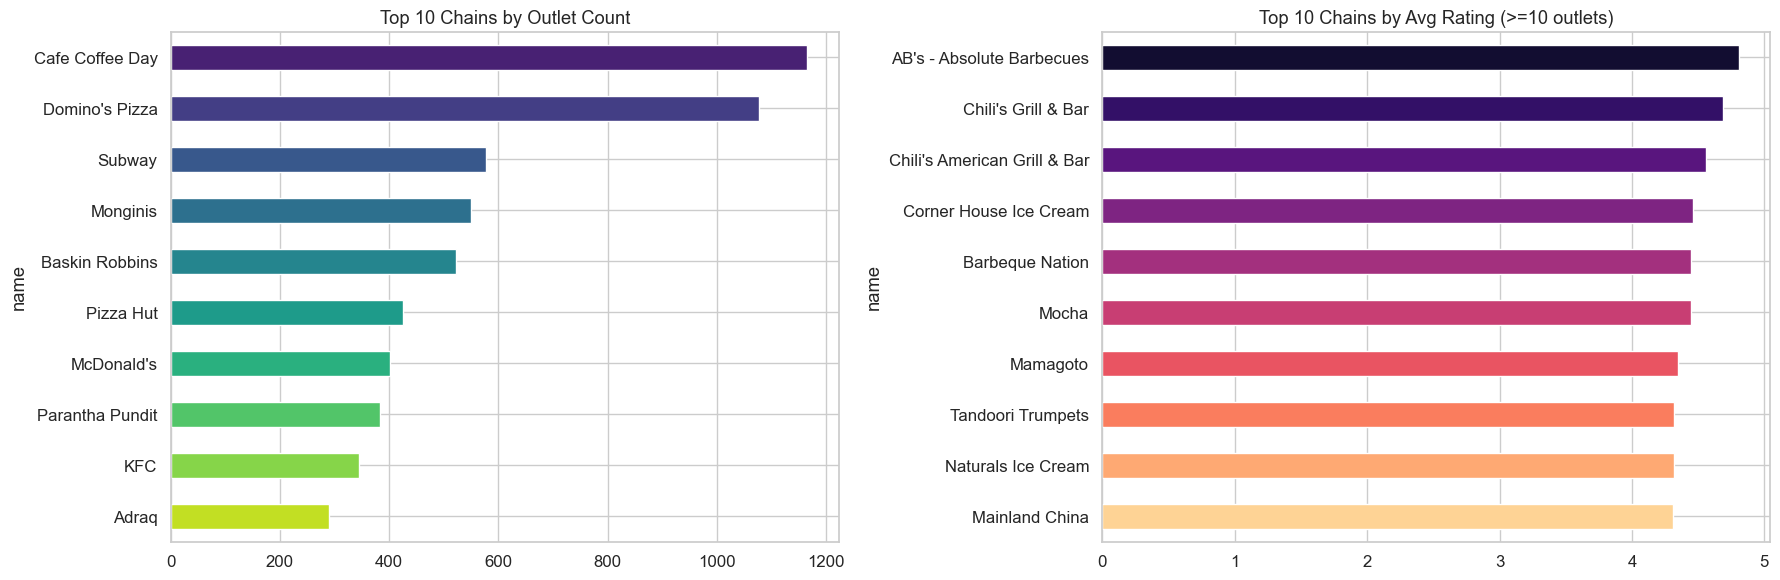

In [7]:
# Visualize the top 10 restaurant chains by outlet count and by average rating.
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
df['name'].value_counts().head(10).plot.barh(ax=axes[0], color=sns.color_palette('viridis', 10))
axes[0].set_title('Top 10 Chains by Outlet Count')
axes[0].invert_yaxis()
big_chains = df_rated['name'].value_counts()
big_chains = big_chains[big_chains >= 10].index
(df_rated[df_rated['name'].isin(big_chains)]
 .groupby('name')['rating'].mean()
 .nlargest(10)
 .plot.barh(ax=axes[1], color=sns.color_palette('magma', 10)))
axes[1].set_title('Top 10 Chains by Avg Rating (>=10 outlets)')
axes[1].invert_yaxis()
plt.tight_layout(); plt.show()

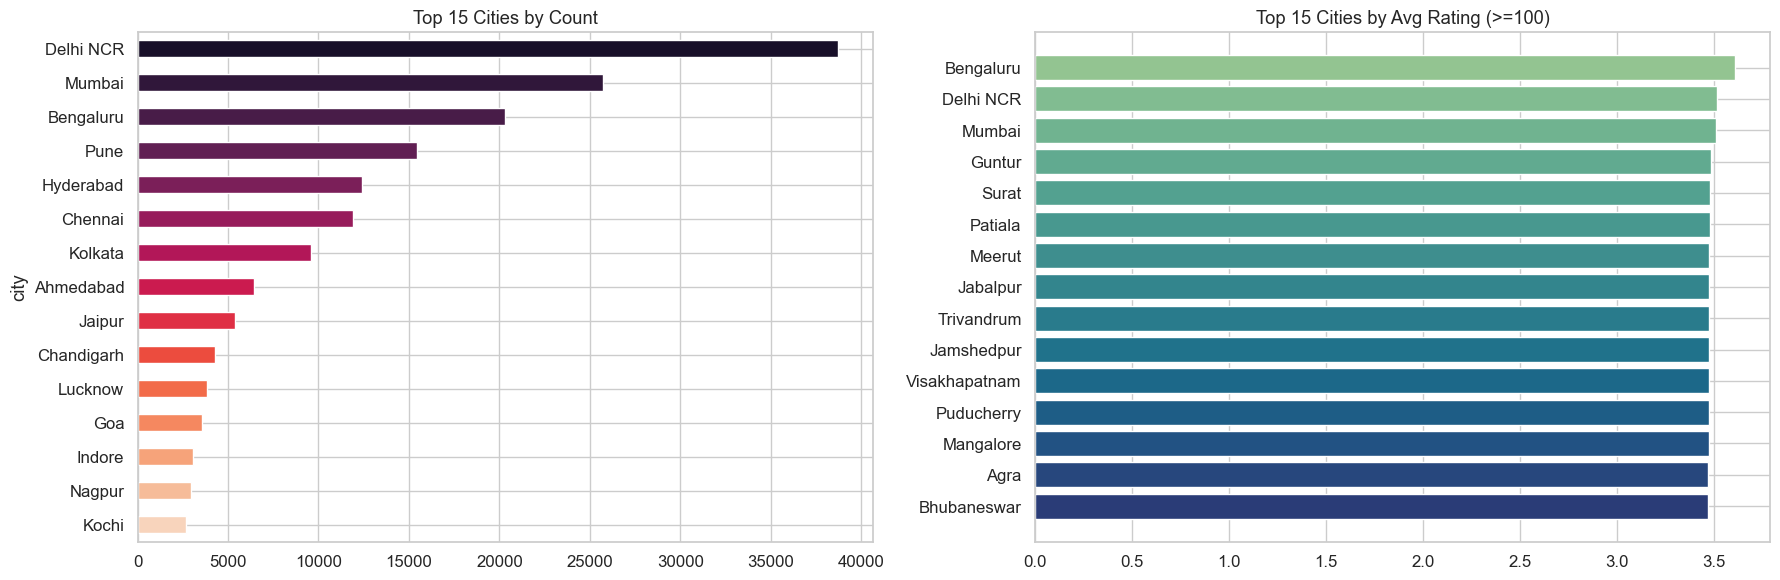

In [8]:
# Visualize the top 15 cities by restaurant count and by average rating.
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
df['city'].value_counts().head(15).plot.barh(ax=axes[0], color=sns.color_palette('rocket', 15))
axes[0].set_title('Top 15 Cities by Count')
axes[0].invert_yaxis()
city_rating = df_rated.groupby('city')['rating'].agg(['mean','count']).query('count >= 100').nlargest(15, 'mean')
axes[1].barh(city_rating.index, city_rating['mean'], color=sns.color_palette('crest', 15))
axes[1].set_title('Top 15 Cities by Avg Rating (>=100)')
axes[1].invert_yaxis()
plt.tight_layout(); plt.show()

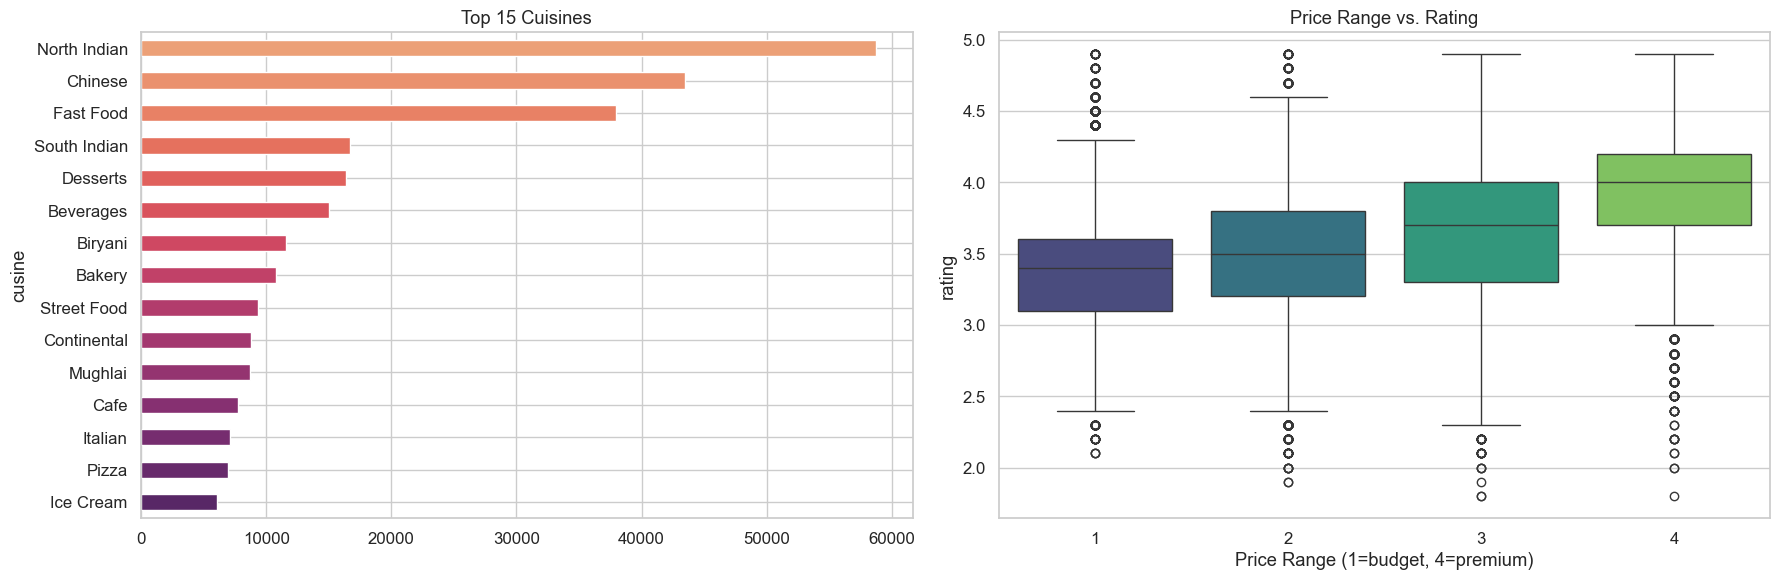

In [9]:
# Visualize the top 15 cuisines and analyze the relationship between price range and rating.
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
all_cuisines.value_counts().head(15).plot.barh(ax=axes[0], color=sns.color_palette('flare', 15))
axes[0].set_title('Top 15 Cuisines')
axes[0].invert_yaxis()
sns.boxplot(data=df_rated, x='price_range', y='rating', palette='viridis', ax=axes[1])
axes[1].set_xlabel('Price Range (1=budget, 4=premium)')
axes[1].set_title('Price Range vs. Rating')
plt.tight_layout(); plt.show()

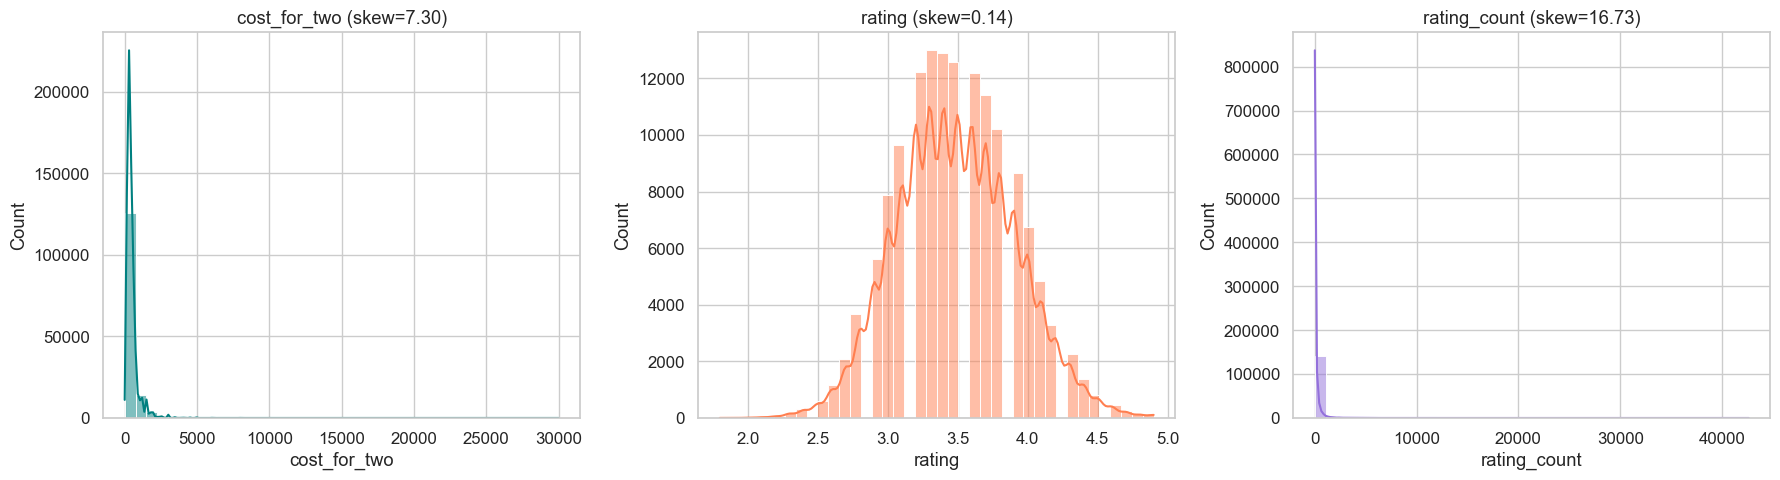

In [10]:
# Plot the distributions (histograms with KDE) for cost, rating, and rating count.
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col, c in zip(axes, ['cost_for_two','rating','rating_count'], ['teal','coral','mediumpurple']):
    sns.histplot(df_rated[col], bins=40, kde=True, ax=ax, color=c)
    ax.set_title(f'{col} (skew={df_rated[col].skew():.2f})')
plt.tight_layout(); plt.show()

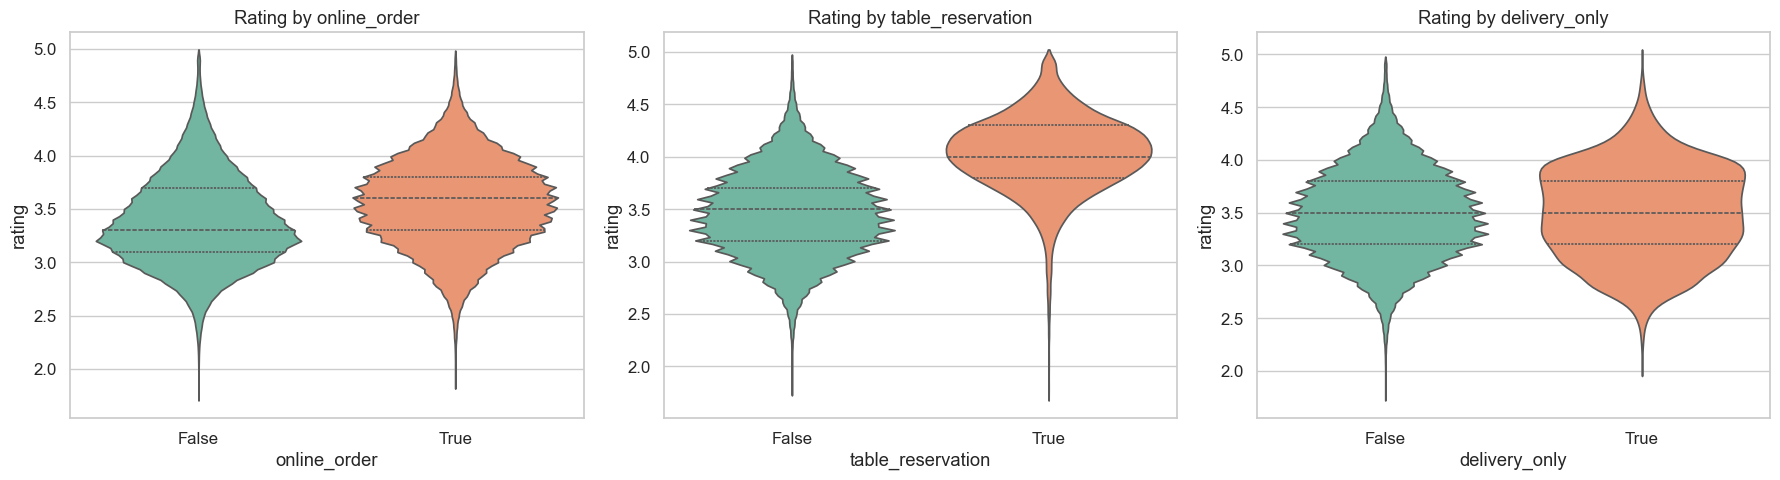

In [11]:
# Use violin plots to show the distribution of ratings across boolean features.
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, BOOL_COLS):
    sns.violinplot(data=df_rated, x=col, y='rating', ax=ax, palette='Set2', inner='quartile')
    ax.set_title(f'Rating by {col}')
plt.tight_layout(); plt.show()

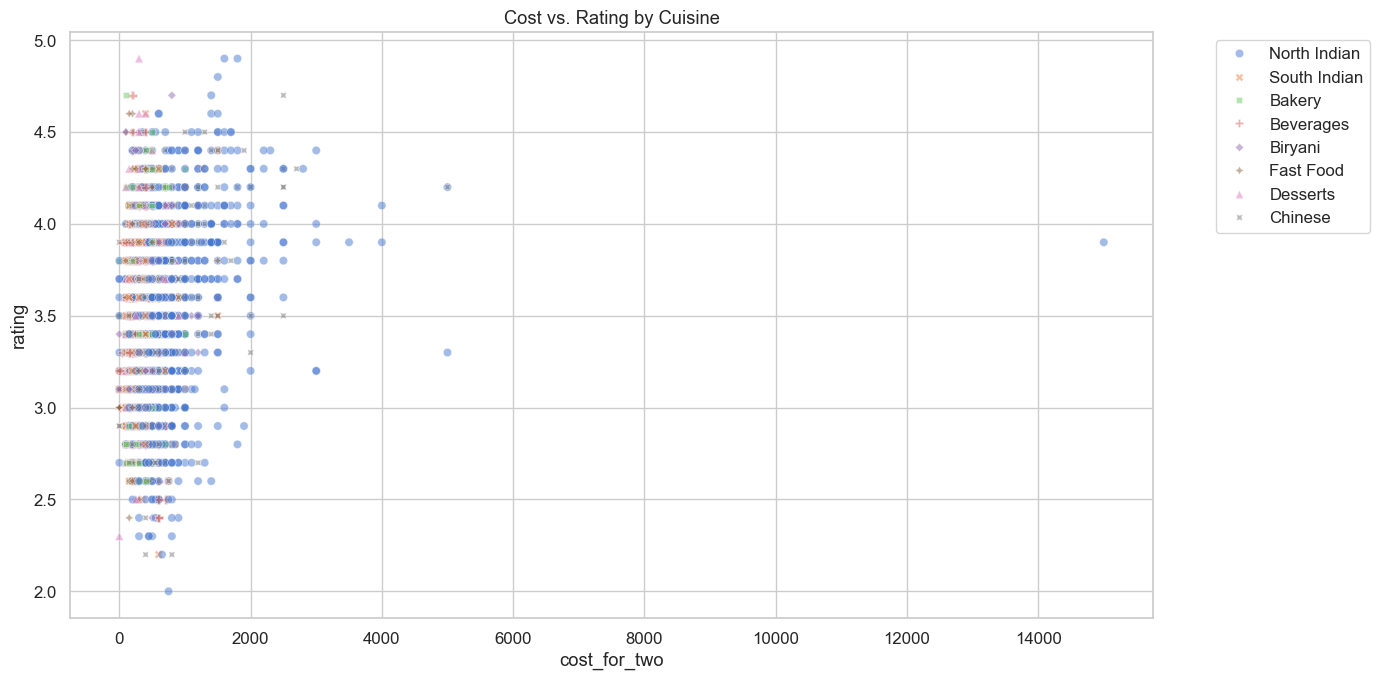

In [12]:
# Scatter plot analyzing cost vs. rating for a sample of the top 8 primary cuisines.
top8 = all_cuisines.value_counts().head(8).index.tolist()
df_rated['primary_cuisine'] = df_rated['cusine'].str.split(',').str[0].str.strip()
sample = df_rated[df_rated['primary_cuisine'].isin(top8)].sample(5000, random_state=42)
fig, ax = plt.subplots(figsize=(14, 7))
sns.scatterplot(data=sample, x='cost_for_two', y='rating',
                hue='primary_cuisine', style='primary_cuisine', alpha=0.5, ax=ax)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_title('Cost vs. Rating by Cuisine')
plt.tight_layout(); plt.show()

In [13]:
# Define a function to identify outliers using IQR and cap the outliers for rating count and cost.
def iqr_bounds(s):
    Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
    IQR = Q3 - Q1
    lo, hi = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_out = ((s < lo) | (s > hi)).sum()
    print(f'{s.name}: bounds=[{lo:.0f}, {hi:.0f}], outliers={n_out} ({n_out/len(s)*100:.1f}%)')
    return lo, hi
for col in ['rating_count', 'cost_for_two']:
    lo, hi = iqr_bounds(df_rated[col])
    df_rated[f'{col}_capped'] = df_rated[col].clip(lo, hi)

rating_count: bounds=[-148, 280], outliers=18149 (12.5%)
cost_for_two: bounds=[-200, 1000], outliers=8448 (5.8%)


In [14]:
# Perform sanity checks comparing our dataset's statistics against the original paper's findings.
city_avg = df_rated.groupby('city')['rating'].agg(['mean','count']).query('count >= 100')
checks = [
    ('Top city by count',  df['city'].value_counts().idxmax(), 'Bangalore'),
    ('Top city by rating', city_avg['mean'].idxmax(), 'Gurgaon'),
    ('Top city by votes',  df_rated.groupby('city')['rating_count'].sum().idxmax(), 'Hyderabad'),
    ('Top cuisine',        all_cuisines.value_counts().idxmax(), 'North Indian'),
]
for label, ours, paper in checks:
    match = 'Y' if ours == paper else 'N'
    print(f'[{match}] {label}: {ours} (paper: {paper})')
band = df_rated['rating'].between(3, 4).mean() * 100
cost = df_rated['cost_for_two'].between(250, 800).mean() * 100
print(f'    3-4 rating band: {band:.1f}%  |  Rs.250-800 range: {cost:.1f}%')

[N] Top city by count: Delhi NCR (paper: Bangalore)
[N] Top city by rating: Bengaluru (paper: Gurgaon)
[N] Top city by votes: Delhi NCR (paper: Hyderabad)
[Y] Top cuisine: North Indian (paper: North Indian)
    3-4 rating band: 81.1%  |  Rs.250-800 range: 69.5%


## Phase 4 — Statistical Validation

In [16]:
# Perform statistical validation: compute Pearson correlation and mean comparisons.
r = df_rated['cost_for_two'].corr(df_rated['rating'])
strength = 'weak' if abs(r) < 0.3 else 'moderate' if abs(r) < 0.7 else 'strong'
print(f'Pearson r={r:.4f} (p-value requires scipy) -> {"positive" if r>0 else "negative"}, {strength}')
g_yes = df_rated.loc[df_rated['online_order'], 'rating']
g_no  = df_rated.loc[~df_rated['online_order'], 'rating']
print(f'Mean rating for Online Order: YES={g_yes.mean():.3f} vs NO={g_no.mean():.3f} (t-test requires scipy)')
top5 = all_cuisines.value_counts().head(5).index
groups = [df_rated.loc[df_rated['cusine'].str.contains(c, case=False, na=False), 'rating'] for c in top5]
print('Top 5 Cuisines Mean Ratings (ANOVA requires scipy):')
for c, g in zip(top5, groups): print(f'  {c:20s} n={len(g):6d} mean={g.mean():.3f}')
print('\nNote: significant p-values show correlation, NOT causation.')

Pearson r=0.2691 (p-value requires scipy) -> positive, weak
Mean rating for Online Order: YES=3.553 vs NO=3.387 (t-test requires scipy)
Top 5 Cuisines Mean Ratings (ANOVA requires scipy):
  North Indian         n= 58732 mean=3.473
  Chinese              n= 43440 mean=3.464
  Fast Food            n= 37984 mean=3.475
  South Indian         n= 16682 mean=3.449
  Desserts             n= 16354 mean=3.581

Note: significant p-values show correlation, NOT causation.
